In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [34]:
file_path = "/content/sales_data_sample.csv"

df = pd.read_csv(file_path, encoding="latin1")

print("Dataset loaded!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded!
Rows: 2823
Columns: 25


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,6505551386,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [12]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

Shape of dataset: (2823, 25)

Column names:
['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE']

Data types:
ORDERNUMBER           int64
QUANTITYORDERED       int64
PRICEEACH           float64
ORDERLINENUMBER       int64
SALES               float64
ORDERDATE            object
STATUS               object
QTR_ID                int64
MONTH_ID              int64
YEAR_ID               int64
PRODUCTLINE          object
MSRP                  int64
PRODUCTCODE          object
CUSTOMERNAME         object
PHONE                object
ADDRESSLINE1         object
ADDRESSLINE2         object
CITY                 object
STATE                object
POSTALCODE           object
COUNTRY              object
TERRITORY            o

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,6505551386,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium



Last 5 rows:


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
2818,10350,20,100.00,15,2244.40,12/2/2004 0:00,Shipped,4,12,2004,Ships,54,S72_3212,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,1/31/2005 0:00,Shipped,1,1,2005,Ships,54,S72_3212,"Oulu Toy Supplies, Inc.",981-443655,Torikatu 38,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,3/1/2005 0:00,Resolved,1,3,2005,Ships,54,S72_3212,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,3/28/2005 0:00,Shipped,1,3,2005,Ships,54,S72_3212,Alpha Cognac,61.77.6555,1 rue Alsace-Lorraine,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small
2822,10414,47,65.52,9,3079.44,5/6/2005 0:00,On Hold,2,5,2005,Ships,54,S72_3212,Gifts4AllAges.com,6175559555,8616 Spinnaker Dr.,NaN,Boston,MA,51003,USA,NaN,Yoshido,Juri,Medium


In [13]:
print("Numerical Summary:")
display(df.describe())

print("\nCategorical Summary:")
display(df.describe(include='object'))

Numerical Summary:


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000



Categorical Summary:


,ORDERDATE,STATUS,PRODUCTLINE,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
count,2823,2823,2823,2823,2823,2823,2823,302,2823,1337,2747,2823,1749,2823,2823,2823
unique,252,6,7,109,92,91,92,9,73,16,73,19,3,77,72,3
top,11/14/2003 0:00,Shipped,Classic Cars,S18_3232,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",Level 3,Madrid,CA,28034,USA,EMEA,Freyre,Diego,Medium
freq,38,2617,967,52,259,259,259,55,304,416,259,1004,1407,259,259,1384


In [14]:
missing_values = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

display(missing_summary)

,Missing Count,Missing Percentage
ADDRESSLINE2,2521,89.302161
STATE,1486,52.639036
POSTALCODE,76,2.692171
TERRITORY,1074,38.044633


In [15]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [16]:
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False).head(20))


ORDERDATE
ORDERDATE
11/14/2003 0:00    38
11/24/2004 0:00    35
11/12/2003 0:00    34
11/17/2004 0:00    32
11/4/2004 0:00     29
10/16/2004 0:00    28
11/5/2003 0:00     28
12/2/2003 0:00     28
11/6/2003 0:00     27
8/20/2004 0:00     27
11/1/2004 0:00     26
10/14/2004 0:00    26
10/22/2004 0:00    26
9/8/2004 0:00      26
11/20/2003 0:00    25
11/5/2004 0:00     25
12/10/2004 0:00    24
11/26/2003 0:00    22
2/17/2005 0:00     22
10/15/2004 0:00    22
Name: count, dtype: int64

STATUS
STATUS
Shipped       2617
Cancelled       60
Resolved        47
On Hold         44
In Process      41
Disputed        14
Name: count, dtype: int64

PRODUCTLINE
PRODUCTLINE
Classic Cars        967
Vintage Cars        607
Motorcycles         331
Planes              306
Trucks and Buses    301
Ships               234
Trains               77
Name: count, dtype: int64

PRODUCTCODE
PRODUCTCODE
S18_3232     52
S12_1666     28
S10_4962     28
S18_1097     28
S10_1949     28
S18_2432     28
S32_2509     28
S2

In [17]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    print(
        f"{column}: "
        f"Min={df[column].min()}, "
        f"Max={df[column].max()}, "
        f"Missing={df[column].isnull().sum()}"
    )

ORDERNUMBER: Min=10100, Max=10425, Missing=0
QUANTITYORDERED: Min=6, Max=97, Missing=0
PRICEEACH: Min=26.88, Max=100.0, Missing=0
ORDERLINENUMBER: Min=1, Max=18, Missing=0
SALES: Min=482.13, Max=14082.8, Missing=0
QTR_ID: Min=1, Max=4, Missing=0
MONTH_ID: Min=1, Max=12, Missing=0
YEAR_ID: Min=2003, Max=2005, Missing=0
MSRP: Min=33, Max=214, Missing=0


In [18]:
df['ORDERDATE'] = pd.to_datetime(
    df['ORDERDATE'],
    errors='coerce'
)

print(df['ORDERDATE'].dtype)
print(df['ORDERDATE'].head())

datetime64[ns]
0   2003-02-24
1   2003-05-07
2   2003-07-01
3   2003-08-25
4   2003-10-10
Name: ORDERDATE, dtype: datetime64[ns]


In [20]:
df['TERRITORY'] = df['TERRITORY'].fillna('Unknown')
df['STATE'] = df['STATE'].fillna('Unknown')
df['ADDRESSLINE2'] = df['ADDRESSLINE2'].fillna('Not Provided')
df['POSTALCODE'] = df['POSTALCODE'].fillna('Unknown')

In [21]:
categorical_columns = [
    'STATUS',
    'PRODUCTLINE',
    'CITY',
    'STATE',
    'COUNTRY',
    'TERRITORY',
    'DEALSIZE'
]

for column in categorical_columns:
    df[column] = df[column].astype(str).str.strip().str.title()

print(df[categorical_columns].head())

    STATUS  PRODUCTLINE           CITY    STATE COUNTRY TERRITORY DEALSIZE
0  Shipped  Motorcycles            Nyc       Ny     Usa   Unknown    Small
1  Shipped  Motorcycles          Reims  Unknown  France      Emea    Small
2  Shipped  Motorcycles          Paris  Unknown  France      Emea   Medium
3  Shipped  Motorcycles       Pasadena       Ca     Usa   Unknown   Medium
4  Shipped  Motorcycles  San Francisco       Ca     Usa   Unknown   Medium


In [22]:
df['CALCULATED_SALES'] = df['QUANTITYORDERED'] * df['PRICEEACH']

df[['QUANTITYORDERED', 'PRICEEACH', 'SALES', 'CALCULATED_SALES']].head()

,QUANTITYORDERED,PRICEEACH,SALES,CALCULATED_SALES
0,30,95.70,2871.00,2871.00
1,34,81.35,2765.90,2765.90
2,41,94.74,3884.34,3884.34
3,45,83.26,3746.70,3746.70
4,49,100.00,5205.27,4900.00


In [23]:
df['SALES_DIFFERENCE'] = (
    df['SALES'] - df['CALCULATED_SALES']
)

print("Maximum difference:",
      df['SALES_DIFFERENCE'].abs().max())

Maximum difference: 7536.5


In [24]:
territory_mapping = {
    'Unknown': 0,
    'EMEA': 1,
    'APAC': 2,
    'Japan': 3
}

df['TERRITORY_ENCODED'] = df['TERRITORY'].map(territory_mapping)

df[['TERRITORY', 'TERRITORY_ENCODED']].head()

,TERRITORY,TERRITORY_ENCODED
0,Unknown,0.0
1,Emea,NaN
2,Emea,NaN
3,Unknown,0.0
4,Unknown,0.0


In [25]:
print("Territory Mapping:")
print(territory_mapping)

Territory Mapping:
{'Unknown': 0, 'EMEA': 1, 'APAC': 2, 'Japan': 3}


In [26]:
scaler = MinMaxScaler()

df['SALES_NORMALIZED'] = scaler.fit_transform(
    df[['SALES']]
)

df[['SALES', 'SALES_NORMALIZED']].head()

,SALES,SALES_NORMALIZED
0,2871.00,0.175644
1,2765.90,0.167916
2,3884.34,0.250150
3,3746.70,0.240030
4,5205.27,0.347273


In [27]:
df['ORDER_YEAR'] = df['ORDERDATE'].dt.year
df['ORDER_MONTH'] = df['ORDERDATE'].dt.month
df['ORDER_DAY'] = df['ORDERDATE'].dt.day

df[['ORDERDATE', 'ORDER_YEAR', 'ORDER_MONTH', 'ORDER_DAY']].head()

,ORDERDATE,ORDER_YEAR,ORDER_MONTH,ORDER_DAY
0,2003-02-24,2003,2,24
1,2003-05-07,2003,5,7
2,2003-07-01,2003,7,1
3,2003-08-25,2003,8,25
4,2003-10-10,2003,10,10


In [28]:
region_sales = (
    df.groupby('TERRITORY')['SALES']
      .sum()
      .sort_values(ascending=False)
)

print("Total Sales by Territory:")
display(region_sales)

Total Sales by Territory:


,SALES
TERRITORY,
Emea,4979272.41
Unknown,3852061.39
Apac,746121.83
Japan,455173.22


In [29]:
region_orders = (
    df.groupby('TERRITORY')['ORDERNUMBER']
      .nunique()
      .sort_values(ascending=False)
)

print("Number of Orders by Territory:")
display(region_orders)

Number of Orders by Territory:


,ORDERNUMBER
TERRITORY,
Emea,151
Unknown,119
Apac,23
Japan,14


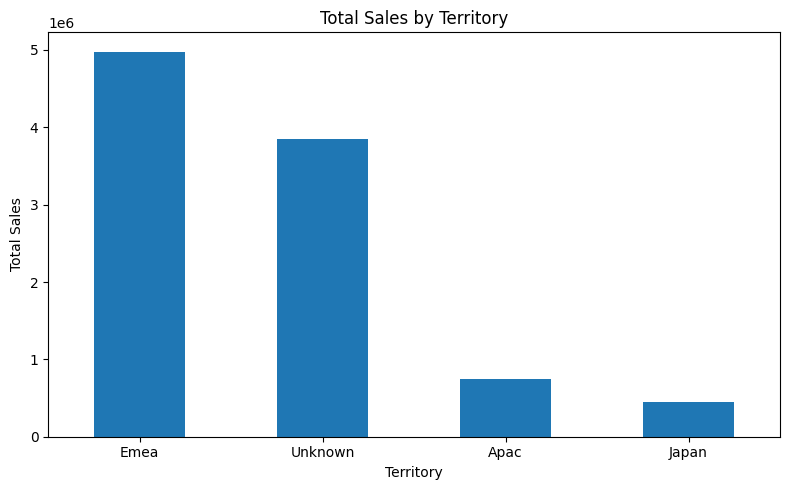

In [30]:
plt.figure(figsize=(8, 5))

region_sales.plot(kind='bar')

plt.title('Total Sales by Territory')
plt.xlabel('Territory')
plt.ylabel('Total Sales')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
print("Missing values after preprocessing:")

final_missing = df.isnull().sum()

display(
    final_missing[final_missing > 0]
)

Missing values after preprocessing:


,0
TERRITORY_ENCODED,1628


In [32]:
print("Final Dataset Shape:", df.shape)

display(df.head())

print("\nFinal Data Types:")
print(df.dtypes)

Final Dataset Shape: (2823, 32)


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,CALCULATED_SALES,SALES_DIFFERENCE,TERRITORY_ENCODED,SALES_NORMALIZED,ORDER_YEAR,ORDER_MONTH,ORDER_DAY
0,10107,30,95.70,2,2871.00,2003-02-24,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,Not Provided,Nyc,Ny,10022,Usa,Unknown,Yu,Kwai,Small,2871.00,0.000000e+00,0.0,0.175644,2003,2,24
1,10121,34,81.35,5,2765.90,2003-05-07,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,Not Provided,Reims,Unknown,51100,France,Emea,Henriot,Paul,Small,2765.90,4.547474e-13,NaN,0.167916,2003,5,7
2,10134,41,94.74,2,3884.34,2003-07-01,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,Not Provided,Paris,Unknown,75508,France,Emea,Da Cunha,Daniel,Medium,3884.34,4.547474e-13,NaN,0.250150,2003,7,1
3,10145,45,83.26,6,3746.70,2003-08-25,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,Not Provided,Pasadena,Ca,90003,Usa,Unknown,Young,Julie,Medium,3746.70,-4.547474e-13,0.0,0.240030,2003,8,25
4,10159,49,100.00,14,5205.27,2003-10-10,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,6505551386,7734 Strong St.,Not Provided,San Francisco,Ca,Unknown,Usa,Unknown,Brown,Julie,Medium,4900.00,3.052700e+02,0.0,0.347273,2003,10,10



Final Data Types:
ORDERNUMBER                   int64
QUANTITYORDERED               int64
PRICEEACH                   float64
ORDERLINENUMBER               int64
SALES                       float64
ORDERDATE            datetime64[ns]
STATUS                       object
QTR_ID                        int64
MONTH_ID                      int64
YEAR_ID                       int64
PRODUCTLINE                  object
MSRP                          int64
PRODUCTCODE                  object
CUSTOMERNAME                 object
PHONE                        object
ADDRESSLINE1                 object
ADDRESSLINE2                 object
CITY                         object
STATE                        object
POSTALCODE                   object
COUNTRY                      object
TERRITORY                    object
CONTACTLASTNAME              object
CONTACTFIRSTNAME             object
DEALSIZE                     object
CALCULATED_SALES            float64
SALES_DIFFERENCE            float64
TERRITORY

In [33]:
output_path = "/content/transformed_sales_data.csv"

df.to_csv(output_path, index=False)

print("Transformed dataset saved successfully!")
print(output_path)

Transformed dataset saved successfully!
/content/transformed_sales_data.csv


# Program 2 — Data Wrangling and Transformation: Summary

## What Was Done

In this program, the sales dataset was loaded and analyzed to understand its structure, data types, categorical variables, numerical variables, missing values, and duplicate records.

The dataset initially contained **2,823 rows and 25 columns**. Missing-value analysis showed missing entries in columns such as `ADDRESSLINE2`, `STATE`, `TERRITORY`, and `POSTALCODE`. No duplicate records were found.

The `ORDERDATE` column was converted from string format into the proper datetime format. Missing categorical values were handled appropriately using `"Unknown"` or `"Not Provided"` where necessary. Postal codes were treated as categorical identifiers rather than numerical values.

Categorical variables were standardized to maintain consistent representations. The `TERRITORY` column was encoded into numerical values so that it could be used in further analysis.

The existing `SALES` values were also validated by calculating sales independently using:

**Quantity Ordered × Price Each**

Date components such as year, month, and day were extracted from the order date to make the data more useful for analysis.

Min-Max normalization was applied to the `SALES` column to scale the values between 0 and 1.

Finally, sales were grouped by territory to understand regional sales performance, and a visualization was created to compare total sales across territories.

## Key Concepts Learned

* Loading and inspecting CSV datasets using Pandas
* Understanding dataset shape, columns, and data types
* Identifying and analyzing missing values
* Detecting duplicate records
* Converting columns to appropriate data types
* Handling missing categorical and identifier values
* Standardizing categorical data
* Creating derived columns
* Extracting useful information from dates
* Encoding categorical variables
* Min-Max normalization of numerical data
* Grouping and aggregating data using `groupby()`
* Validating existing data using calculated values
* Visualizing aggregated data
* Exporting the cleaned and transformed dataset to CSV

## Final Outcome

The raw sales dataset was successfully cleaned, transformed, validated, analyzed, and prepared for further data analysis. The final dataset contains standardized values, encoded categorical information, normalized sales values, extracted date features, and no remaining missing values in the processed fields.

The transformed dataset was saved as:

`transformed_sales_data.csv`
